- Kyle Vogel (xbu7xh), 3/25/2026, DS 3021

#### Week 8 Lab - Linear Regression

---

##### Q0.

1. What makes a model "linear"? "Linear" in what? A model is linear in the coefficients. A model is considered linear if the model is the sum of terms. $x$ variables can be transformed by being squared, or with logarithmics, but variables like beta must stay simple terms.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.) There's further explanation at the end of this document, if needed. The coefficient tells you the difference between the actual outcome that ocurred and the predicted group from the beginning. The intercept is the predicted group, and the dummy variable shifts you away from the predicted.

3. Can linear regression be used for classification? Explain why, or why not. No, linear regression should not be used for classification because it can give outputs outside of the 0 to 1 requirement for probabilities. The probability of an event ocurring cannot be less than 0% or greater than 100%, so this should not be used.

4. If you have a high accuracy on training but low on testing, what might be the problem? It also might be you see a pattern in the residuals. This likely means that the model is overfitting, and is still learning patterns specific to the trianing that don't actually generalize with the testing data.

5. Review this page: [Non-Linear with Linear](https://inria.github.io/scikit-learn-mooc/python_scripts/linear_regression_non_linear_link.html) What are two ways to incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$? Polynomial feature expansion creates new features and adds abilities to the functions in your mode. The second way is via binning. Binning separates the variable into different ranges and then treats each range as a category. This helps the model catch any patterns that may be nonlinear. 

6. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable? The intercept is the predicted value of our target variable when the other features of our model are 0. The slope coefficient for a variable shows us the relationship between unit increases with how they effect our target variable y. The coefficient for a dummy/one-hot-encoded variable is the difference in the predicted y between that given category and its baseline group.

---

##### Q1

Dataset: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [9]:
df = pd.read_csv("Q1_data.csv")
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [10]:
# Now let's group the rows by their borough and find the averages for price and rating
BoroughPrice = df.groupby("Neighbourhood")[["Price", "Review Scores Rating"]].mean()
BoroughPrice.sort_values(by="Price", ascending=False)

,Price,Review Scores Rating
Neighbourhood,,
Manhattan,183.664286,91.801496
Staten Island,146.166667,90.843750
Brooklyn,127.747378,92.363497
Queens,96.857233,91.549057
Bronx,75.276498,91.654378


This tells us that on average Manhattan is the most expensive neighborhood, and Brooklyn has the highest Review Scores Rating. Now let's create a KDE plot to show this:

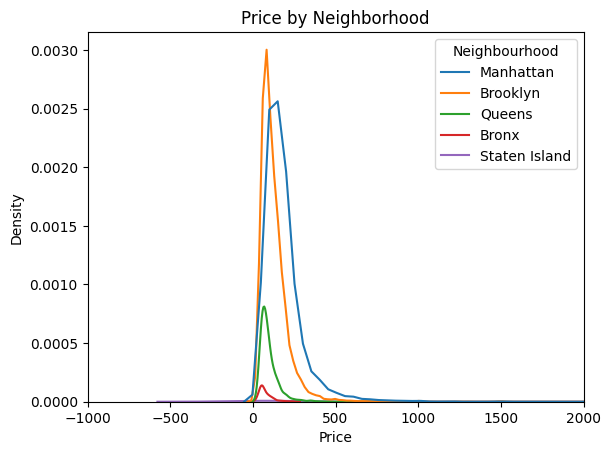

In [11]:
sns.kdeplot(data=df, x="Price", hue="Neighbourhood")
plt.title("Price by Neighborhood")
plt.xlim(-1000, 2000)
plt.show()

Now let's also create a KDE graph for Log_Price instead of Price to more clearly see the shape of the distribution, and erase some of the outliers. The price KDE above seems to be pretty skewed to the right due to a few very high-priced listings which makes it harder to see the distributions.

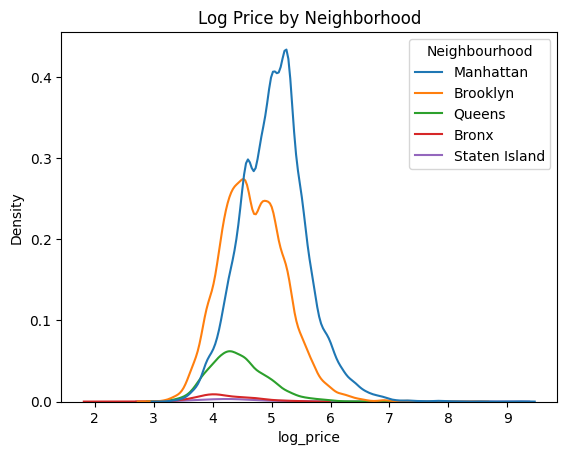

In [12]:
df["log_price"] = np.log(df["Price"])

sns.kdeplot(data=df, x="log_price", hue="Neighbourhood")
plt.title("Log Price by Neighborhood")
plt.show()

There we go. Now we can see a much more evenly distributed visual of price listings by neighborhood.

In [13]:
# Now we encode our dummy variable without dropping to to get rid of the intercept

DummyVar = pd.get_dummies(df["Neighbourhood"])
DummyVar.head()

,Bronx,Brooklyn,Manhattan,Queens,Staten Island
0,False,False,True,False,False
1,False,True,False,False,False
2,False,False,True,False,False
3,False,True,False,False,False
4,False,False,True,False,False


In [14]:
# Okay, now let's compare the coefficients in regression to the table that we had previously.
from sklearn.linear_model import LinearRegression

ModelBuild = LinearRegression(fit_intercept=False)

# Now we must define our variables
X = DummyVar
Y = df["Price"]

ModelBuild.fit(X, Y)

# Now let's see those coefficients
Coefficents = pd.Series(ModelBuild.coef_, index = X.columns)
print(Coefficents)

Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
dtype: float64


These are the same numbers that we calculated previously, so the model seems to be learning the average price per borough.

In [15]:
# Now let's what the coefficients are in a regression of a continous variable on one categorical

Compare = pd.DataFrame({"Regression Coefficient": Coefficents, "Average $ Per Group": BoroughPrice["Price"]})
print(Compare)

               Regression Coefficient  Average $ Per Group
Bronx                       75.276498            75.276498
Brooklyn                   127.747378           127.747378
Manhattan                  183.664286           183.664286
Queens                      96.857233            96.857233
Staten Island              146.166667           146.166667


Yeah, so we can pretty clearly see here that it is the exact same. When I regress a continuous variable on one categorical data even without an intercept it just takes the average.

In [16]:
# Now we're asked to repeat everything, except with an intercept this time
# This time you handle t he creation of the dummies differently by including the drop

DummyVar = pd.get_dummies(df["Neighbourhood"], drop_first=True)
DummyVar.head()

,Brooklyn,Manhattan,Queens,Staten Island
0,False,True,False,False
1,True,False,False,False
2,False,True,False,False
3,True,False,False,False
4,False,True,False,False


In [17]:
# Next, let's fit the regression with the model like we did before, this time with the intercept
# Let's redefine X and Y to make sure they updated
X = DummyVar
Y = df["Price"]

ModelBuild = LinearRegression()
ModelBuild.fit(X, Y)

# Now we have to pass a series argument to get the coefficients and intercepts
Coefficents = pd.Series(ModelBuild.coef_, index = X.columns)
Intercept = ModelBuild.intercept_

print("Intercept: ", Intercept)
print(Coefficents)

Intercept:  75.27649769585331
Brooklyn          52.470881
Manhattan        108.387789
Queens            21.580735
Staten Island     70.890169
dtype: float64


As you can see, the intercept is 75.28, and each coefficient represents the average price of the baseline home in the given borough.

In [18]:
# We can get the coefficients in part 2 from these new coefficients by simply adding them to the intercept:

TheyAreBack = Coefficents + Intercept
TheyAreBack["Baseline"] = Intercept
TheyAreBack

Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
Baseline          75.276498
dtype: float64

In [19]:
# Now for #4 we have to create a dummy variable again for neighborhood and drop because we're going to be using an intercept

X = pd.get_dummies(df[["Review Scores Rating", "Neighbourhood"]], drop_first=True)
Y = df["Price"]

In [ ]:
# Now we make the 80/20 like we're asked to do through train,test,split:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Let's fit our model again
ModelBuild = LinearRegression()
ModelBuild.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
# Now let's see the prediction on our current testing set

Y_predicted = ModelBuild.predict(X_test)
print(Y_predicted)

[138.51239286 178.01899608 138.51239286 ... 185.51328855 184.2642398
 189.26043478]


In [22]:
# Now it asks us to find the R^2 and RSME of the test set

from sklearn.metrics import r2_score, mean_squared_error

R2 = r2_score(Y_test, Y_predicted)
RMSE = np.sqrt(mean_squared_error(Y_test, Y_predicted))

print("The R2 is:", R2)
print("The RMSE is", RMSE)

The R2 is: 0.0585448286341137
The RMSE is 128.3202429795853


We can tell from those values above that our testing model isn't the best.

In [23]:
# Now it asks us to get the coefficient on Review Scores Rating

Coefficents = pd.Series(ModelBuild.coef_, index=X.columns)
Coefficents["Review Scores Rating"]
print(Coefficents)

Review Scores Rating             1.249049
Neighbourhood_Brooklyn          53.742997
Neighbourhood_Manhattan        109.487234
Neighbourhood_Queens            21.815136
Neighbourhood_Staten Island     21.120551
dtype: float64


In [29]:
# And now for the most expensive kind of property you can rent:

inercept = ModelBuild.intercept_

borough_coefficent = Coefficents.filter(like="Neighbourhood")
(borough_coefficent + inercept).sort_values(ascending=False)

Neighbourhood_Manhattan        69.351755
Neighbourhood_Brooklyn         13.607518
Neighbourhood_Queens          -18.320343
Neighbourhood_Staten Island   -19.014928
dtype: float64

Here you can see the most expensive kind of property you can rent is in the neighborhood of Manhattan. When we add teh intercept back to it, it tells us how far above or below the baseline each one is.

In [30]:
# Now we're asked to go ahead and add Property Type to our model. We still have to drop because we're using the intercept

X = pd.get_dummies(df[["Review Scores Rating", "Neighbourhood", "Property Type"]], drop_first=True)
Y = df["Price"]

In [ ]:
# Now let's train, test, split like we did before

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

ModelBuild = LinearRegression()
ModelBuild.fit(X_train, Y_train)

#Prediction on our current test set
Y_predicted = ModelBuild.predict(X_test)
print(Y_predicted)

[131.83469451 176.74817907 131.83469451 ... 184.10607217 182.87975665
 187.78501872]


In [32]:
# Let's recompute the R^2 and RMSE like it asks..

R2 = r2_score(Y_test, Y_predicted)
RMSE = np.sqrt(mean_squared_error(Y_test, Y_predicted))

print("The R2 is:", R2)
print("The RMSE is:", RMSE)

The R2 is: 0.07192660388315852
The RMSE is: 127.40501178778167


Hard to tell but it does look like the model slightly improved. Likely to us adding more variables to the mix and making it more complex..

In [33]:
# It asks us to review Scores Rating coefficents again..

Coefficents = pd.Series(ModelBuild.coef_, index=X.columns)
Coefficents["Review Scores Rating"]
Coefficents

Review Scores Rating             1.226316e+00
Neighbourhood_Brooklyn           6.195164e+01
Neighbourhood_Manhattan          1.228072e+02
Neighbourhood_Queens             2.843716e+01
Neighbourhood_Staten Island      1.507336e+01
Property Type_Bed & Breakfast   -3.158758e+01
Property Type_Boat               5.781137e+01
Property Type_Bungalow           8.349031e+01
Property Type_Cabin             -7.105427e-15
Property Type_Camper/RV         -1.927943e+01
Property Type_Castle            -4.269028e+01
Property Type_Chalet             4.174439e-14
Property Type_Condominium        6.092789e+01
Property Type_Dorm              -4.563648e+01
Property Type_House              3.201019e+01
Property Type_Hut               -1.353324e+02
Property Type_Lighthouse         1.776357e-15
Property Type_Loft               6.404618e+01
Property Type_Other              1.747732e+01
Property Type_Townhouse          6.239656e+01
Property Type_Treehouse          9.568596e+00
Property Type_Villa              3

It looks like the most expensive property you can rent would be a Bunglow here. Quite pricey

If the Review Scores Rating changes from part 4 to part 5, you know that it is due to adding more sophistication to the model. In part 5 we added in the Property Type category which added another element to the model and gave it more information. That controls for a variable that was missing previously, so the Review Scores Rating is no longer biased based on differences in property types.

---

#### Q2.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
# Now let's clean this new dataset

df = pd.read_csv('cars_hw.csv')
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


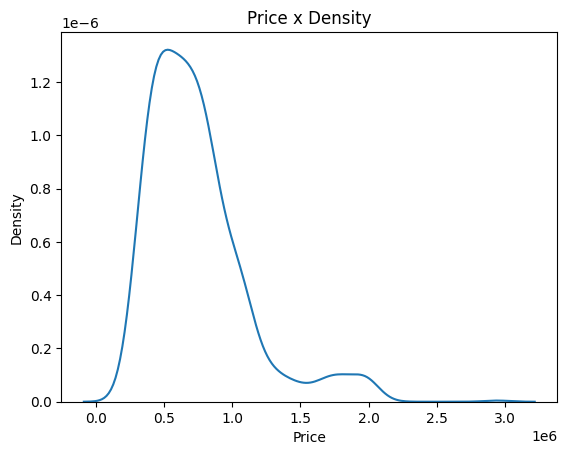

In [39]:
# Let's make a KDE plot to see if it is skewed

sns.kdeplot(df["Price"])
plt.title("Price x Density")
plt.show()

Oh yeah wow skewed right

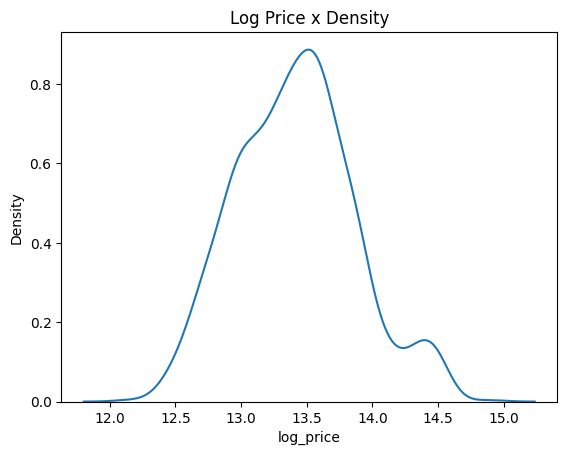

In [40]:
#Let's check the log price with a KDE plot now to see if it is still an issue

df["log_price"] =  np.log(df["Price"])

sns.kdeplot(df["log_price"])
plt.title("Log Price x Density")
plt.show()

No not too bad at all. I think we can proceed forward with this data just using the log price transformation to correct for the skew. There doesn't seem to be anything else we need to clean

In [44]:
# It asks us to summarize price
df["Price"].describe()

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64

In [45]:
# Now let's summarize by brand

df.groupby("Make")["Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Make,,,,,,,,
Chevrolet,6.0,4.535000e+05,2.466064e+05,267000.0,288500.0,345500.0,537500.0,892000.0
Datsun,3.0,2.896667e+05,1.050397e+04,279000.0,284500.0,290000.0,295000.0,300000.0
Ford,52.0,7.211731e+05,1.409277e+05,290000.0,635000.0,707500.0,787000.0,1066000.0
Honda,73.0,7.989726e+05,2.665091e+05,316000.0,581000.0,785000.0,915000.0,1537000.0
Hyundai,305.0,6.918918e+05,2.791597e+05,248000.0,485000.0,638000.0,837000.0,1742000.0
Jeep,4.0,1.499500e+06,1.525134e+05,1290000.0,1447500.0,1529500.0,1581500.0,1649000.0
Kia,8.0,1.614750e+06,1.190567e+05,1369000.0,1579000.0,1628500.0,1705750.0,1741000.0
MG Motors,35.0,1.869457e+06,1.216611e+05,1589000.0,1786500.0,1848000.0,1978000.0,2019000.0
Mahindra,18.0,1.100167e+06,1.755493e+05,796000.0,1037000.0,1094500.0,1157000.0,1465000.0


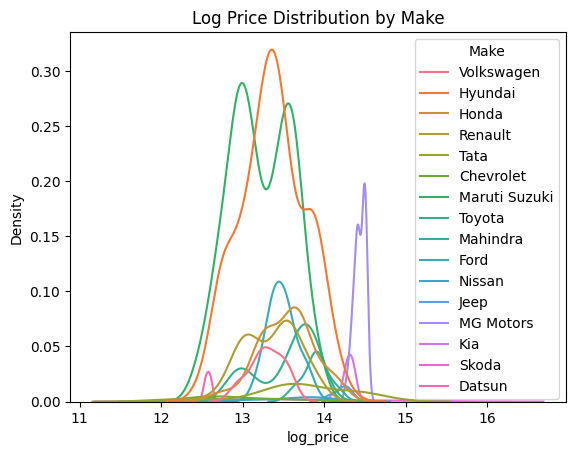

In [51]:
# Now let's make that KDE plot showing all this

sns.kdeplot(df, x="log_price", hue="Make")
plt.title("Log Price Distribution by Make")
plt.show()

Woah that is one crazy KDE. I think it may be a bit right skewed but hard to tell.

In [52]:
# Okay, now it asks us to split the data into 80% trainingg and 20% testing again..

Y = df["log_price"]
X = df.drop(columns=["log_price"])

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(780, 12) (196, 12)
(780,) (196,)


In [55]:
# Okay, let's begin working on that numeric variable model first

numeric_cols = X.select_dtypes(include=np.number).columns

# Now let's train the model
numeric_model = LinearRegression()
numeric_model.fit(X_train[numeric_cols],Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
# Now we have to find the R2 on both the training set and test set

predicted_train = numeric_model.predict(X_train[numeric_cols])
predicted_test = numeric_model.predict(X_test[numeric_cols])

In [59]:
# Now let's display the R2 scores and the RMSE for the them
Training_R2 = r2_score(Y_train, predicted_train)
Testing_R2 = r2_score(Y_test, predicted_test)
rmse_test = np.sqrt(mean_squared_error(Y_test, predicted_test))

#printing our new values
print("Training R2:", Training_R2)
print("Testing R2:", Testing_R2)
print("RMSE:", rmse_test)

Training R2: 0.9276537804888936
Testing R2: 0.9205115429391448
RMSE: 0.12312075701305693


In [63]:
# Now let's start on teh categorical model

Categorical_cols = X.select_dtypes(exclude=np.number).columns

In [65]:
# It tells us to one-hot-encode and use the drop feature

X_Categorical = pd.get_dummies(X[Categorical_cols], drop_first=True)

# Now we have to create train and test variables
Train_Categ_x = X_Categorical.loc[X_train.index]
Test_Categ_x =  X_Categorical.loc[X_test.index]

# Now let's train the model
Categorical_model = LinearRegression()
Categorical_model.fit(Train_Categ_x, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [66]:
# Now let's find the R2 and RMSE values for the categorical test set
pred_test_cat = Categorical_model.predict(Test_Categ_x)

Categ_R2 = r2_score(Y_test, pred_test_cat)
Categ_RMSE = np.sqrt(mean_squared_error(Y_test, pred_test_cat))

print("The Categorical R2:", Categ_R2)
print("The Categorical RMSE:", Categ_RMSE)

The Categorical R2: 0.6535045874136006
The Categorical RMSE: 0.2570561437633287


You can easily tell that the numerical model performed much better than the categorical did by the testing R2 and RMSE values

In [ ]:
# Now let's repeat the steps and make the combined model:

X_Combo = pd.get_dummies(X, drop_first=True)
X_Training_Combo = X_Combo.loc[X_train.index]
X_Testing_Combo = X_Combo.loc[X_test.index]

# Now we train the model like we have before..
Combo_Model = LinearRegression()
Combo_Model.fit(X_Training_Combo, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [69]:
# Now let's evaluate the model like we have before..

Combo_Predict_testing = Combo_Model.predict(X_Testing_Combo)

R2_Combo = r2_score(Y_test, Combo_Predict_testing)
RMSE_Combo = np.sqrt(mean_squared_error(Y_test, Combo_Predict_testing))

print("The Combo R2 is:", R2_Combo)
print("The Comvo RMSE is:", RMSE_Combo)

The Combo R2 is: 0.9575252621388443
The Comvo RMSE is: 0.0900004326554014


Wow that performed far and away better than the other two. The R2 was 0.3 higher than the categorical model and 0.03 better than the numeric. The RMSE was 0.16 better than the categorical model and 0.03 better than the numeric. Wow!

In [91]:
# Now time to create this polynomial model

from sklearn.preprocessing import PolynomialFeatures

# Here we can edit the degree of expansion ands see later how that R2 and RMSE changes
Polynomial = PolynomialFeatures(degree=5)

# Build the teraining and testing models..
X_train_polynom = Polynomial.fit_transform(X_train[numeric_cols])
X_test_polynom = Polynomial.transform(X_test[numeric_cols])

In [92]:
# Now let's create the way to check the R2 and RMSE like we have before
poly_model = LinearRegression()
poly_model.fit(X_train_polynom, Y_train)

# Let's make the model prediction here
pred_poly = poly_model.predict(X_test_polynom)

R2_Polynom = r2_score(Y_test, pred_poly)
RMSE_Polynom = np.sqrt(mean_squared_error(Y_test, pred_poly))

# And display results
print("The Polynomial R2 is:", R2_Polynom)
print("The Polynomial RMSE is:", RMSE_Polynom)

The Polynomial R2 is: 0.9970177485238467
The Polynomial RMSE is: 0.023847967694019572


As I adjusted the degree of expansion from 1 up, I noticed it quickly improved the model, lowering the RMSE and increasing the R2 very close to 1. Then, all of a sudden when I got to 5 and increased from there is began to quickly degrade the model and make it much much worse. As I reached 10 degrees of expansion, the R2 was in the negatives.

I think this compares very well with our model from part 4. My R2 and RMSE values are even higher than they were for the combo model that I made previously. Getting an R2 of 0.997 and an RMSE of 0.02 is very impressive and shows that it is a good model.

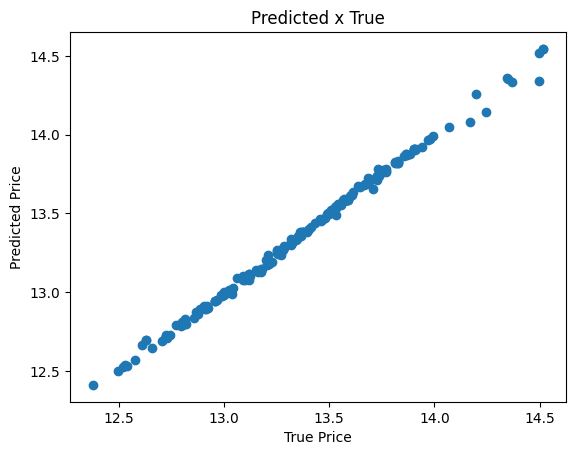

In [95]:
# Now it asks me to take the best model so far (Polynomial model at degree = 5) and plot it

plt.scatter(Y_test, pred_poly)
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("Predicted x True")
plt.show()

Wow that is insane. It predicted it insanely well. They line up just about perfectly.

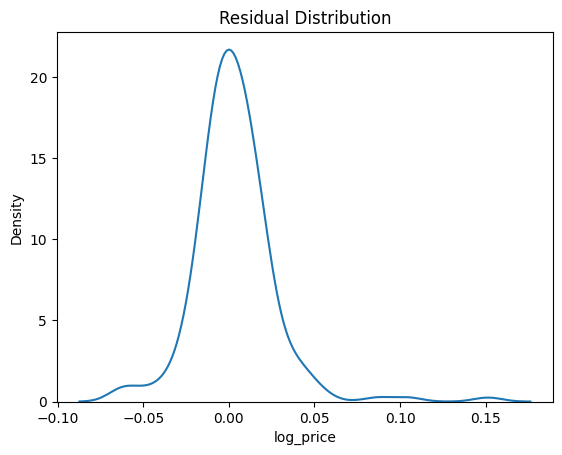

In [96]:
# Now it asks me to compute the residuals and create a KDE

Resid = Y_test - pred_poly

sns.kdeplot(Resid)
plt.title("Residual Distribution")
plt.show()

Yeah the residuals are definitely bell-shaped around zero. It looks slightly skewed right, but I can say for certain the data is very compact and there aren't many outliers. I would say the model is pretty damn strong, giving me predicted values that are extremely close to the actual values. A potential weakness may be the outlier values that are really evident in this bell shaped model here. There just seem to be a lot of values on that right side there

---

#### Q3.

In [ ]:
# I'm choosing the NBA 2020 playoff games do this on

df = pd.read_csv("nba_playoffs_games.csv")
df.head()

,series_id,home_team,away_team,home_points,away_points,round,game,score_home,score_away
0,1,MIL,ORL,110,122,1,1,0,0
1,1,MIL,ORL,111,96,1,2,0,1
2,1,ORL,MIL,107,121,1,3,1,1
3,1,ORL,MIL,106,121,1,4,1,2
4,1,MIL,ORL,118,104,1,5,3,1


In [ ]:
# Let's see what the column names are that we're working with here
print(df.columns)

Index(['series_id', 'home_team', 'away_team', 'home_points', 'away_points',
       'round', 'game', 'score_home', 'score_away'],
      dtype='str')


In [ ]:
# Let's drop and values of 0 and missing values to clean the data up
df.isnull().sum()
df = df.dropna()

In [ ]:
# I'm going to go with the home_points variable and try to learn more about that
df["home_points"].describe()

count     66.000000
mean     109.606061
std       13.841830
min       80.000000
25%      100.250000
50%      108.500000
75%      118.000000
max      154.000000
Name: home_points, dtype: float64

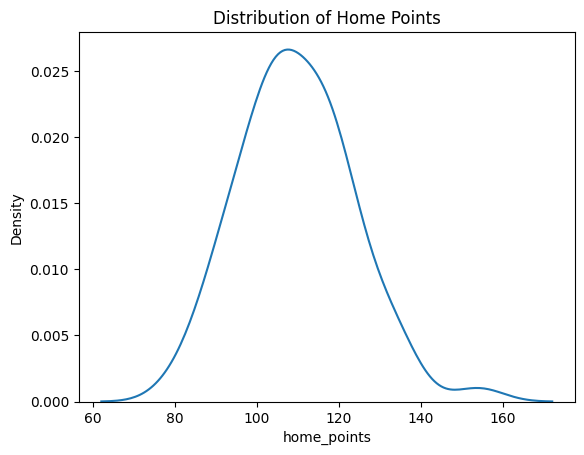

In [105]:
# Let's build this KDE plot to see the distribution of home points in the playoffs
sns.kdeplot(df, x="home_points")
plt.title("Distribution of Home Points")
plt.show()

You can see that home team in the playoffs in 2020 scored as low as 80 and as high as 154, with a mean at 109. The data does not look to be very skewed, it has a nice bell shape.

In [108]:
# Now let's build our model with the target and the predicters

Y = df["home_points"]
X = df.drop(columns=["home_points"])

# Let's split the data into the normal 80/20 split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(52, 8) (14, 8)
(52,) (14,)


In [ ]:
# Now let's build a model of the numerical values only:

X_numeric = df[["series_id", "away_points", "round", "game", "score_home", "score_away"]]

Xnum_train, Xnum_test, Ynum_train, Ynum_test = train_test_split(X_numeric, Y, test_size=0.2, random_state=42)

NumModel = LinearRegression()
NumModel.fit(Xnum_train, Ynum_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# Now let's get the R2 and RMSE for this model:

PredictedNum = NumModel.predict(Xnum_test)

RMSE_numeric = np.sqrt(mean_squared_error(Ynum_test, PredictedVals))
R2_numeric = r2_score(Ynum_test, PredictedVals)

print("Numeric Model RMSE:", RMSE_numeric)
print("Numeric Model R2:", R2_numeric)

Numeric Model RMSE: 12.559992058324912
Numeric Model R2: -0.04922686548631572


Well that's not very good

In [115]:
# Now let's make the categorical model

X_Cat = pd.get_dummies(df[["home_team", "away_team"]], drop_first=True)

Xc_train, Xc_test, Yc_train, Yc_test = train_test_split(X_Cat, Y, test_size=0.2, random_state=42)

CategModel = LinearRegression()
CategModel.fit(Xc_train, Yc_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# Now let's get the predictions and RMSE for the categorical model

PredictedCat = CategModel.predict(Xc_test)

RMSE_categ = np.sqrt(mean_squared_error(Yc_test, Predictions2))
R2_categ = r2_score(Yc_test, Predictions2)

print("Categorical Model RMSE:", RMSE_categ)
print("Categorical Model R2:", R2_categ)

Categorical Model RMSE: 17.348836930962918
Categorical Model R2: -1.0018494010655266


In [121]:
# Now let's make that combined model:

X_combined = pd.concat([X_numeric, X_Cat], axis=1)

Xcombo_train, Xcombo_test, Ycombo_train, Ycombo_test = train_test_split(X_combined, Y, test_size=0.2, random_state=42)

ComboModel = LinearRegression()
ComboModel.fit(Xcombo_train, Ycombo_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [124]:
# Now let's see how the combined model did:

PredictedCombo = ComboModel.predict(Xcombo_test)

RMSE_combo = np.sqrt(mean_squared_error(Ycombo_test, PredictedCombo))
R2_combo = r2_score(Ycombo_test, PredictedCombo)


print("Combined Model RMSE:", RMSE_combo)
print("Combined Model R2:", R2_combo)

Combined Model RMSE: 18.788614465667585
Combined Model R2: -1.3479031719345986


Although all of the models performed rather poorly, the numeric model performed the best here as it had the lowest RMSE and highesr R2 of the 3 models. This shows us that of the 3 models this one does the best job of predicting the playoff home points values compared to the other similar models.

I learned that when building a model you really need to choose a dataset that has a substantial amount of data within it. This dataset was incredibly small because it only pulls from 2020 NBA playoff games which there were only 66 of. This limits us and may have impacted the actual takeaways that could've been made had we used a dataset of EVERY nba playoff game. This was an incredibly fun activity and I feel like I learned a lot from going through these motions and working on this lab.